# Phân tích Dữ liệu Ga tàu London TfL
Notebook này thực hiện quy trình từ tải dữ liệu, làm sạch, phân cụm thống kê đến xây dựng bản đồ tương tác để phân tích lưu lượng hành khách và tác động của COVID-19.

In [2]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================

# !pip install -q folium geopandas scikit-learn plotly pandas numpy

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import folium
from folium.plugins import MarkerCluster, HeatMap
import xml.etree.ElementTree as ET
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported")


✓ All libraries imported


### 1. Tải và Xử lý Dữ liệu Thô
Bước này định nghĩa hàm `load_kml` để trích xuất tọa độ địa lý và đọc các file CSV chứa thông tin về lưu lượng hành khách cũng như thông tin hành chính (Borough).

In [3]:
def load_kml(filepath):
    """Parse KML file với error handling"""
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
        ns = {'kml': 'http://www.opengis.net/kml/2.2'}

        stations_list = []
        for pm in root.findall('.//kml:Placemark', ns):
            try:
                name = pm.find('kml:name', ns).text.strip()
                clean_name = name.replace(' Station', '').strip()
                coords = pm.find('.//kml:coordinates', ns).text.strip().split(',')

                stations_list.append({
                    'station': clean_name,
                    'lat': float(coords[1]),
                    'lon': float(coords[0])
                })
            except Exception as e:
                print(f"  ⚠️ Skip placemark: {e}")
                continue

        kml_df = pd.DataFrame(stations_list)
        print(f"✓ Loaded KML: {len(kml_df)} stations")
        return kml_df

    except Exception as e:
        print(f"✗ Error loading KML: {e}")
        return None

csv_data = pd.read_csv('TfL_stations.csv')
csv_data.rename(columns={'Station': 'station'}, inplace=True)
csv_data['station'] = csv_data['station'].str.strip()
print(f"✓ Loaded CSV: {len(csv_data)} stations")

# Load stops for borough info
df_stops = pd.read_csv('Stops.csv', engine='python', on_bad_lines='skip')
print(f"✓ Loaded Stops: {len(df_stops)} entries")

# Parse KML
kml_df = load_kml('/content/stations .kml')


✓ Loaded CSV: 436 stations
✓ Loaded Stops: 69418 entries
✓ Loaded KML: 302 stations


### 2. Hợp nhất Dữ liệu (Merging)
Hàm này kết nối các nguồn dữ liệu khác nhau dựa trên tên ga. Đây là bước quan trọng để kết hợp tọa độ từ KML với số liệu thống kê từ CSV.

In [4]:
def merge_and_validate(kml_df, csv_data, df_stops):
    """Merge data sources + check quality"""

    print("\n" + "="*70)
    print("MERGING & VALIDATING DATA")
    print("="*70)

    # Before merge
    print(f"\nBefore merge:")
    print(f"  KML:      {len(kml_df):5d} stations")
    print(f"  CSV:      {len(csv_data):5d} stations")
    print(f"  Stops:    {len(df_stops):5d} entries")

    # Merge 1: KML + CSV
    df = pd.merge(kml_df, csv_data, on='station', how='left')
    matched = df['station'].notna().sum()

    print(f"\nAfter CSV merge: {matched}/{len(kml_df)} stations matched")

    # Find unmatched
    unmatched_kml = kml_df[~kml_df['station'].isin(csv_data['station'])]
    if len(unmatched_kml) > 0:
        print(f"⚠️ Unmatched from KML (examples):")
        print(unmatched_kml['station'].head(5).to_list())

    # Merge 2: Add borough info
    df = pd.merge(
        df,
        df_stops[['CommonName', 'Town']].drop_duplicates('CommonName'),
        left_on='station',
        right_on='CommonName',
        how='left'
    )

    df.rename(columns={'Town': 'borough'}, inplace=True)
    df.drop(columns=['CommonName'], inplace=True)

    matched_borough = df['borough'].notna().sum()
    print(f"After borough merge: {matched_borough}/{len(df)} have borough info")

    print(f"\n✓ Final merged data: {len(df)} stations")
    return df

# Execute merge
df = merge_and_validate(kml_df, csv_data, df_stops)


MERGING & VALIDATING DATA

Before merge:
  KML:        302 stations
  CSV:        436 stations
  Stops:    69418 entries

After CSV merge: 307/302 stations matched
⚠️ Unmatched from KML (examples):
['Acton Town', 'Aldgate', 'Aldgate East', 'Baker Street', 'Balham']
After borough merge: 5/307 have borough info

✓ Final merged data: 307 stations


### 3. Làm sạch và Chuẩn hóa
Ở bước này, chúng ta chuyển đổi dữ liệu hành khách sang dạng số, tính toán số lượng tuyến đường (`num_lines`) và loại bỏ các ga thiếu dữ liệu quan trọng để đảm bảo tính chính xác cho các bước phân tích sau.

In [5]:
def clean_and_standardize(df):
    """Clean & prepare data for analysis"""

    print("\n" + "="*70)
    print("CLEANING & STANDARDIZING DATA")
    print("="*70)

    # 1. Clean passenger data
    print("\n1. Processing passenger data (2017-2021)...")
    years = [2017, 2018, 2019, 2020, 2021]
    passenger_cols = ['En/Ex 2017', 'En/Ex 2018', 'En/Ex 2019', 'En/Ex 2020', 'En/Ex 2021']

    for year, col in zip(years, passenger_cols):
        if col in df.columns:
            df[f'passengers_{year}'] = pd.to_numeric(
                df[col].astype(str).str.replace(',', ''),
                errors='coerce'
            )

    # 2. Handle LINES (number of lines) - IMPORTANT FIX
    print("2. Processing number of lines...")
    df['num_lines'] = df['LINES'].fillna('').astype(str).str.count(',') + 1
    df.loc[df['LINES'].isna(), 'num_lines'] = 0

    # 3. Check missing data
    print("\n3. Missing data before cleaning:")
    critical_cols = ['lat', 'lon', 'passengers_2021', 'num_lines']
    missing_stats = df[critical_cols].isnull().sum()
    for col, count in missing_stats.items():
        pct = (count / len(df)) * 100
        print(f"   {col:20s}: {count:6d} ({pct:5.1f}%)")

    # 4. Drop rows with critical missing data
    df_clean = df.dropna(subset=['lat', 'lon', 'passengers_2021']).copy()

    print(f"\n✓ Data cleaned: {len(df_clean)}/{len(df)} stations retained")

    # 5. Show data sample
    print("\nSample data (first 5 rows):")
    print(df_clean[['station', 'lat', 'lon', 'passengers_2021', 'num_lines']].head())

    return df_clean

# Execute cleaning
df = clean_and_standardize(df)


CLEANING & STANDARDIZING DATA

1. Processing passenger data (2017-2021)...
2. Processing number of lines...

3. Missing data before cleaning:
   lat                 :      0 (  0.0%)
   lon                 :      0 (  0.0%)
   passengers_2021     :    123 ( 40.1%)
   num_lines           :      0 (  0.0%)

✓ Data cleaned: 184/307 stations retained

Sample data (first 5 rows):
       station        lat       lon  passengers_2021  num_lines
3     Alperton  51.540695 -0.299487        1345253.0          1
4     Amersham  51.674150 -0.607479         946577.0          1
5        Angel  51.532499 -0.105790        7258744.0          1
6      Archway  51.565427 -0.135114        4027456.0          1
7  Arnos Grove  51.616340 -0.133516        1963343.0          1


### 4. Phân cụm Thông minh (Clustering)
Sử dụng thuật toán KMeans để nhóm các ga có đặc điểm tương đồng về lưu lượng và vị trí. Tên các nhóm (như Mega Hub, Small Station) được gán tự động dựa trên xếp hạng lưu lượng thực tế.

In [6]:
def smart_clustering(df, n_clusters=6):
    """KMeans clustering + stats-based naming (NOT hardcoded)"""

    print("\n" + "="*70)
    print("CLUSTERING ANALYSIS")
    print("="*70)

    # Prepare features
    features = ['passengers_2021', 'num_lines', 'lat', 'lon']
    X = StandardScaler().fit_transform(df[features])

    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster_id'] = kmeans.fit_predict(X)

    # Analyze each cluster
    print("\nCluster Statistics:")
    print("-" * 90)

    cluster_profiles = []
    for cid in sorted(df['cluster_id'].unique()):
        cluster_data = df[df['cluster_id'] == cid]

        count = len(cluster_data)
        avg_passengers = cluster_data['passengers_2021'].mean()
        avg_lines = cluster_data['num_lines'].mean()
        avg_passengers_2017 = cluster_data['passengers_2017'].mean()

        profile = {
            'cluster_id': cid,
            'count': count,
            'pct_of_total': (count / len(df)) * 100,
            'avg_passengers': avg_passengers,
            'avg_lines': avg_lines,
            'avg_passengers_2017': avg_passengers_2017
        }
        cluster_profiles.append(profile)

        growth = ((avg_passengers - avg_passengers_2017) / avg_passengers_2017 * 100)

        print(f"Cluster {cid}: {count:4d} stations | "
              f"Passengers: {avg_passengers:12,.0f} | "
              f"Lines: {avg_lines:5.2f} | "
              f"Growth: {growth:+6.1f}%")

    # AUTO-ASSIGN NAMES BASED ON PASSENGERS (RANKING)
    print("\n📊 Assigning names based on passenger volume...")
    cluster_profiles_sorted = sorted(cluster_profiles,
                                     key=lambda x: x['avg_passengers'],
                                     reverse=True)

    names = [
        "Mega Hub",           # Tier 1: Largest
        "Major Central",      # Tier 2
        "Large Station",      # Tier 3
        "Medium Station",     # Tier 4
        "Small Station",      # Tier 5
        "Minor Station"       # Tier 6: Smallest
    ]

    cluster_name_mapping = {}
    for rank, profile in enumerate(cluster_profiles_sorted):
        cid = profile['cluster_id']
        name = names[rank] if rank < len(names) else f"Cluster {rank}"
        cluster_name_mapping[cid] = name

    df['cluster_name'] = df['cluster_id'].map(cluster_name_mapping)

    print("\n✓ Cluster Mapping:")
    for cid in sorted(cluster_name_mapping.keys()):
        name = cluster_name_mapping[cid]
        count = len(df[df['cluster_id'] == cid])
        avg_pass = df[df['cluster_id'] == cid]['passengers_2021'].mean()
        print(f"  Cluster {cid} → {name:20s} ({count:4d} stations, {avg_pass:12,.0f} avg passengers)")

    return df

# Execute clustering
df = smart_clustering(df, n_clusters=6)


CLUSTERING ANALYSIS

Cluster Statistics:
------------------------------------------------------------------------------------------
Cluster 0:   34 stations | Passengers:    1,303,018 | Lines:  1.00 | Growth:  -55.5%
Cluster 1:   37 stations | Passengers:    3,700,613 | Lines:  1.00 | Growth:  -58.2%
Cluster 2:   25 stations | Passengers:    1,337,642 | Lines:  1.00 | Growth:  -53.7%
Cluster 3:   30 stations | Passengers:    1,237,161 | Lines:  1.00 | Growth:  -54.9%
Cluster 4:   50 stations | Passengers:    1,997,565 | Lines:  1.00 | Growth:  -53.0%
Cluster 5:    8 stations | Passengers:    8,272,331 | Lines:  1.00 | Growth:  -56.2%

📊 Assigning names based on passenger volume...

✓ Cluster Mapping:
  Cluster 0 → Small Station        (  34 stations,    1,303,018 avg passengers)
  Cluster 1 → Major Central        (  37 stations,    3,700,613 avg passengers)
  Cluster 2 → Medium Station       (  25 stations,    1,337,642 avg passengers)
  Cluster 3 → Minor Station        (  30 stations

### 5. Phân tích Tác động COVID-19
Tính toán tỷ lệ sụt giảm hành khách trong đại dịch (2019-2020) và tốc độ hồi phục sau đó (2020-2021) cho từng nhóm ga.

In [7]:
def analyze_covid_impact(df):
    """Calculate COVID-19 impact metrics"""

    print("\n" + "="*70)
    print("COVID-19 IMPACT ANALYSIS")
    print("="*70)

    # Impact: 2019 → 2020
    df['covid_impact_pct'] = (
        (df['passengers_2020'] - df['passengers_2019'])
        / df['passengers_2019'] * 100
    )

    # Recovery: 2020 → 2021
    df['recovery_rate_pct'] = (
        (df['passengers_2021'] - df['passengers_2020'])
        / df['passengers_2020'] * 100
    )

    print("\n📊 Overall Impact (2019→2020):")
    print(f"  Average:  {df['covid_impact_pct'].mean():+7.2f}%")
    print(f"  Worst:    {df['covid_impact_pct'].min():+7.2f}%")
    print(f"  Best:     {df['covid_impact_pct'].max():+7.2f}%")

    print("\n📈 Recovery Rate (2020→2021):")
    print(f"  Average:  {df['recovery_rate_pct'].mean():+7.2f}%")
    print(f"  Min:      {df['recovery_rate_pct'].min():+7.2f}%")
    print(f"  Max:      {df['recovery_rate_pct'].max():+7.2f}%")

    # Analysis by cluster
    print("\n🎯 Impact by Cluster:")
    print("-" * 70)
    for cname in sorted(df['cluster_name'].unique()):
        cluster_data = df[df['cluster_name'] == cname]
        avg_impact = cluster_data['covid_impact_pct'].mean()
        avg_recovery = cluster_data['recovery_rate_pct'].mean()

        impact_emoji = "🔴" if avg_impact < -30 else "🟡" if avg_impact < -10 else "🟢"

        print(f"{impact_emoji} {cname:20s}: Impact={avg_impact:+7.2f}% | Recovery={avg_recovery:+7.2f}%")

    return df

# Execute COVID analysis
df = analyze_covid_impact(df)


COVID-19 IMPACT ANALYSIS

📊 Overall Impact (2019→2020):
  Average:   -51.24%
  Worst:     -90.20%
  Best:      -15.66%

📈 Recovery Rate (2020→2021):
  Average:    +1.95%
  Min:       -51.34%
  Max:      +361.56%

🎯 Impact by Cluster:
----------------------------------------------------------------------
🔴 Large Station       : Impact= -56.26% | Recovery= +21.56%
🔴 Major Central       : Impact= -57.63% | Recovery=  +7.62%
🔴 Medium Station      : Impact= -42.03% | Recovery= -19.52%
🔴 Mega Hub            : Impact= -67.40% | Recovery= +72.32%
🔴 Minor Station       : Impact= -46.76% | Recovery= -13.52%
🔴 Small Station       : Impact= -43.81% | Recovery= -20.21%


### 6. Phân tích Xu hướng Dài hạn
Sử dụng hồi quy tuyến tính (Linear Regression) để xác định xem một ga đang trong xu hướng tăng trưởng hay suy giảm lưu lượng trong giai đoạn 5 năm.

In [8]:
def analyze_trends(df):
    """Calculate passenger trends with linear regression"""

    print("\n" + "="*70)
    print("TIME-SERIES TREND ANALYSIS")
    print("="*70)

    years = np.array([2017, 2018, 2019, 2020, 2021]).reshape(-1, 1)

    trends = []

    for _, row in df.iterrows():
        passengers = np.array([
            row['passengers_2017'],
            row['passengers_2018'],
            row['passengers_2019'],
            row['passengers_2020'],
            row['passengers_2021']
        ])

        # Only fit if no NaN values
        if not np.isnan(passengers).any():
            lr = LinearRegression()
            lr.fit(years, passengers)
            slope = lr.coef_[0]
            trends.append(slope)
        else:
            trends.append(np.nan)

    df['trend_slope'] = trends

    # Categorize trends
    def categorize_trend(slope):
        if pd.isna(slope):
            return 'Unknown'
        elif slope > 150000:
            return '⬆️ Strong Growing'
        elif slope > 0:
            return '⬆️ Slight Growing'
        elif slope > -150000:
            return '⬇️ Slight Declining'
        else:
            return '⬇️ Strong Declining'

    df['trend_category'] = df['trend_slope'].apply(categorize_trend)

    # Show distribution
    print("\nTrend Distribution:")
    trend_counts = df['trend_category'].value_counts()
    for trend, count in trend_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {trend:25s}: {count:4d} stations ({pct:5.1f}%)")

    # Top growing
    print("\n🏆 Top 10 Fastest Growing Stations:")
    top_growth = df.nlargest(10, 'trend_slope')[['station', 'trend_slope', 'cluster_name']]
    for i, (_, row) in enumerate(top_growth.iterrows(), 1):
        print(f"  {i:2d}. {row['station']:35s} {row['trend_slope']:+10,.0f}/year ({row['cluster_name']})")

    # Top declining
    print("\n📉 Top 10 Fastest Declining Stations:")
    top_decline = df.nsmallest(10, 'trend_slope')[['station', 'trend_slope', 'cluster_name']]
    for i, (_, row) in enumerate(top_decline.iterrows(), 1):
        print(f"  {i:2d}. {row['station']:35s} {row['trend_slope']:+10,.0f}/year ({row['cluster_name']})")

    return df

# Execute trend analysis
df = analyze_trends(df)



TIME-SERIES TREND ANALYSIS

Trend Distribution:
  ⬇️ Strong Declining      :  174 stations ( 94.6%)
  ⬇️ Slight Declining      :   10 stations (  5.4%)

🏆 Top 10 Fastest Growing Stations:
   1. Pudding Mill Lane                      -10,522/year (Large Station)
   2. Roding Valley                          -66,465/year (Medium Station)
   3. Chigwell                               -82,653/year (Medium Station)
   4. West India Quay                        -96,117/year (Large Station)
   5. North Ealing                          -114,828/year (Small Station)
   6. Grange Hill                           -115,963/year (Medium Station)
   7. Moor Park                             -118,790/year (Minor Station)
   8. Gallions Reach                        -123,304/year (Large Station)
   9. Theydon Bois                          -135,876/year (Medium Station)
  10. Beckton Park                          -136,890/year (Large Station)

📉 Top 10 Fastest Declining Stations:
   1. Old Street             

### 7. Bản đồ Tương tác và Báo cáo
Cuối cùng, chúng ta tạo bản đồ Folium với các vòng tròn có kích thước tỷ lệ với lưu lượng, kèm theo bảng tóm tắt các chỉ số quan trọng và xuất kết quả ra file Excel/CSV.

In [ ]:
def create_interactive_map(df):
    """Create Folium map with cluster colors and popups"""

    print("\n" + "="*70)
    print("CREATING INTERACTIVE MAP")
    print("="*70)

    # Center on London
    m = folium.Map(
        location=[51.5074, -0.1278],
        zoom_start=11,
        tiles="CartoDB positron"
    )

    # Color mapping for clusters
    colors = {
        'Mega Hub': '#e41a1c',           # Red
        'Major Central': '#377eb8',       # Blue
        'Large Station': '#4daf4a',       # Green
        'Medium Station': '#984ea3',      # Purple
        'Small Station': '#ff7f00',       # Orange
        'Minor Station': '#ffff33'        # Yellow
    }

    # Add markers
    for _, row in df.iterrows():
        # Only plot if we have good data
        if pd.notna(row['lat']) and pd.notna(row['lon']):

            # Create popup HTML
            popup_html = f"""
            <div style="font-family: Arial; width: 300px;">
                <h4 style="margin-bottom: 5px;">{row['station']}</h4>
                <hr style="margin: 5px 0;">

                <b>Cluster:</b> {row['cluster_name']}<br>
                <b>Borough:</b> {row['borough'] if pd.notna(row['borough']) else 'N/A'}<br>
                <b>Lines:</b> {int(row['num_lines'])}<br>
                <br>

                <b>Passengers 2021:</b> {row['passengers_2021']:,.0f}<br>
                <b>Trend:</b> {row['trend_category']}<br>
                <b>COVID Impact:</b> {row['covid_impact_pct']:+.1f}%<br>
                <br>

                <b>5-Year Trend:</b><br>
                2017: {row['passengers_2017']:,.0f}<br>
                2018: {row['passengers_2018']:,.0f}<br>
                2019: {row['passengers_2019']:,.0f}<br>
                2020: {row['passengers_2020']:,.0f}<br>
                2021: {row['passengers_2021']:,.0f}
            </div>
            """

            color = colors.get(row['cluster_name'], '#999999')

            # Size based on passengers
            radius = 3 + (row['passengers_2021'] / df['passengers_2021'].max()) * 8

            folium.CircleMarker(
                location=[row['lat'], row['lon']],
                radius=radius,
                popup=folium.Popup(popup_html, max_width=350),
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.7,
                weight=1
            ).add_to(m)

    # Add heatmap layer (optional)
    heat_data = [[row['lat'], row['lon'], row['passengers_2021']/1000000]
                 for _, row in df.iterrows() if pd.notna(row['lat'])]
    HeatMap(heat_data, radius=15, blur=25, max_zoom=1).add_to(m)

    # Save map
    m.save('london_tfl_stations_map.html')
    print("✓ Saved: london_tfl_stations_map.html")

    return m

# Create map
map_london = create_interactive_map(df)


CREATING INTERACTIVE MAP
✓ Saved: london_tfl_stations_map.html


In [ ]:
from IPython.display import HTML

# Đọc trực tiếp file HTML và nhúng vào notebook để tránh lỗi 'refused to connect'
with open('london_tfl_stations_map.html', 'r') as f:
    html_data = f.read()

HTML(html_data)

In [ ]:
import base64
from IPython.display import HTML

# Đọc file và mã hóa base64 để nhúng trực tiếp vào iframe
with open('london_tfl_stations_map.html', 'r') as f:
    html_content = f.read()
    b64_content = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')

# Tạo iframe hiển thị từ dữ liệu base64
display(HTML(f'<iframe src="data:text/html;base64,{b64_content}" width="100%" height="600px" style="border:none;"></iframe>'))

In [ ]:
def generate_summary_report(df):
    """Generate comprehensive summary report"""

    print("\n" + "="*70)
    print("SUMMARY REPORT & KEY INSIGHTS")
    print("="*70)

    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  Total Stations:        {len(df):,d}")
    print(f"  Total Lines:           {int(df['num_lines'].sum()):,d}")
    print(f"  Total Passengers 2021: {df['passengers_2021'].sum():,.0f}")
    print(f"  Total Passengers 2017: {df['passengers_2017'].sum():,.0f}")

    overall_change = ((df['passengers_2021'].sum() - df['passengers_2017'].sum())
                     / df['passengers_2017'].sum() * 100)
    print(f"  Overall Change:        {overall_change:+.1f}%")

    print(f"\n🏪 CLUSTER STATISTICS:")
    cluster_summary = df.groupby('cluster_name').agg({
        'station': 'count',
        'passengers_2021': ['mean', 'sum'],
        'num_lines': 'mean'
    }).round(0)
    cluster_summary.columns = ['Count', 'Avg Passengers', 'Total Passengers', 'Avg Lines']
    print(cluster_summary)

    print(f"\n TOP 10 STATIONS BY PASSENGERS (2021):")
    top10 = df.nlargest(10, 'passengers_2021')[['station', 'passengers_2021', 'cluster_name']]
    for i, (_, row) in enumerate(top10.iterrows(), 1):
        print(f"  {i:2d}. {row['station']:35s} {row['passengers_2021']:12,.0f} ({row['cluster_name']})")

    print(f"\n📈 COVID-19 MOST AFFECTED:")
    most_affected = df.nsmallest(5, 'covid_impact_pct')[['station', 'covid_impact_pct', 'recovery_rate_pct']]
    for i, (_, row) in enumerate(most_affected.iterrows(), 1):
        print(f"  {i}. {row['station']:35s} Impact={row['covid_impact_pct']:+6.1f}% Recovery={row['recovery_rate_pct']:+6.1f}%")

    print(f"\n BEST RECOVERED:")
    best_recovery = df.nlargest(5, 'recovery_rate_pct')[['station', 'covid_impact_pct', 'recovery_rate_pct']]
    for i, (_, row) in enumerate(best_recovery.iterrows(), 1):
        print(f"  {i}. {row['station']:35s} Recovery={row['recovery_rate_pct']:+6.1f}% (from {row['covid_impact_pct']:+6.1f}%)")

# Generate report
generate_summary_report(df)



SUMMARY REPORT & KEY INSIGHTS

📊 OVERALL STATISTICS:
  Total Stations:        184
  Total Lines:           184
  Total Passengers 2021: 417,838,093
  Total Passengers 2017: 945,654,479
  Overall Change:        -55.8%

🏪 CLUSTER STATISTICS:
                Count  Avg Passengers  Total Passengers  Avg Lines
cluster_name                                                      
Large Station      50       1997565.0        99878239.0        1.0
Major Central      37       3700613.0       136922690.0        1.0
Medium Station     25       1337642.0        33441057.0        1.0
Mega Hub            8       8272331.0        66178647.0        1.0
Minor Station      30       1237161.0        37114844.0        1.0
Small Station      34       1303018.0        44302616.0        1.0

 TOP 10 STATIONS BY PASSENGERS (2021):
   1. North Greenwich                       11,279,522 (Mega Hub)
   2. Old Street                             9,635,310 (Mega Hub)
   3. Camden Town                            9,118,

In [ ]:
def export_results(df):
    """Export results to multiple formats"""

    print("\n" + "="*70)
    print("EXPORTING RESULTS")
    print("="*70)

    # Select columns to export
    export_cols = [
        'station', 'lat', 'lon', 'cluster_id', 'cluster_name',
        'borough', 'num_lines',
        'passengers_2017', 'passengers_2018', 'passengers_2019',
        'passengers_2020', 'passengers_2021',
        'covid_impact_pct', 'recovery_rate_pct',
        'trend_slope', 'trend_category'
    ]

    df_export = df[export_cols].copy()

    # 1. CSV
    df_export.to_csv('london_tfl_analysis.csv', index=False)
    print("✓ Saved: london_tfl_analysis.csv")

    # 2. Excel with summary
    with pd.ExcelWriter('london_tfl_analysis.xlsx', engine='openpyxl') as writer:
        df_export.to_excel(writer, sheet_name='Stations', index=False)

        # Summary by cluster
        summary = df.groupby('cluster_name').agg({
            'station': 'count',
            'passengers_2021': ['mean', 'sum'],
            'num_lines': 'mean',
            'covid_impact_pct': 'mean',
            'recovery_rate_pct': 'mean'
        }).round(2)
        summary.to_excel(writer, sheet_name='Summary by Cluster')

    print("✓ Saved: london_tfl_analysis.xlsx")

    return True

# Export
export_results(df)

print("\n" + "="*70)
print(" ANALYSIS COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Saved: london_tfl_analysis.csv
✓ Saved: london_tfl_analysis.xlsx

 ANALYSIS COMPLETE!


## 7. Đánh giá bộ dữ liệu
- **Ưu điểm**: Dữ liệu TfL rất chi tiết, phản ánh rõ nét tác động của các sự kiện xã hội (COVID-19) lên hạ tầng đô thị.
- **Hạn chế**: Tỷ lệ dữ liệu thiếu (missing values) ở các ga nhỏ khá cao (khoảng 40% ở năm 2021), gây khó khăn cho việc phân tích toàn diện 100% mạng lưới.

## 8. Kết luận
Dự án đã xây dựng thành công pipeline ETL tự động hóa từ khâu tiền xử lý đến trực quan hóa. Kết quả phân tích cho thấy sự hồi phục không đồng đều giữa các nhóm ga, trong đó các **Mega Hub** có tốc độ hồi phục ấn tượng nhất sau đại dịch, dù chịu ảnh hưởng nặng nề nhất về số lượng tuyệt đối.

In [24]:
def validate_and_merge_data(kml_df, csv_data, df_stops):
    """
    Hợp nhất dữ liệu với kiểm tra chất lượng
    """
    print("="*60)
    print("BƯỚC 1: KIỂM ĐỊNH DỮ LIỆU")
    print("="*60)

    # Kiểm tra dữ liệu đầu vào
    print(f"\n1. Kích thước dữ liệu:")
    print(f"   - KML stations: {len(kml_df)}")
    print(f"   - CSV data: {len(csv_data)}")
    print(f"   - Stops: {len(df_stops)}")

    # Merge bước 1: KML + CSV (Sửa 'Station' thành 'station')
    df = pd.merge(kml_df, csv_data, on='station', how='left')
    matched_csv = df['station'].notna().sum()
    print(f"\n2. Sau merge với CSV: {matched_csv}/{len(kml_df)} stations matched")

    # Xem stations không match được (Sửa 'Station' thành 'station')
    unmatched = kml_df[~kml_df['station'].isin(csv_data['station'])]['station'].head(5)
    if len(unmatched) > 0:
        print(f"   ⚠️ Ví dụ stations không match: {unmatched.tolist()}")

    # Merge bước 2: Thêm Borough info
    df = pd.merge(df, df_stops[['CommonName', 'Town']].drop_duplicates('CommonName'),
                  left_on='station', right_on='CommonName', how='left')
    df.rename(columns={'Town': 'borough'}, inplace=True)
    df.drop(columns=['CommonName'], inplace=True)

    matched_borough = df['borough'].notna().sum()
    print(f"\n3. Sau merge với Borough: {matched_borough}/{len(df)} có borough info")

    return df

In [25]:
def clean_and_standardize_data(df):
    """
    Làm sạch dữ liệu và thống nhất naming
    """
    print("\n" + "="*60)
    print("BƯỚC 2: LÀM SẠCH & TIÊU CHUẨN HÓA DỮ LIỆU")
    print("="*60)

    # 1. Xử lý passenger data với error handling
    passenger_cols = ['En/Ex 2017', 'En/Ex 2018', 'En/Ex 2019', 'En/Ex 2020', 'En/Ex 2021']
    for i, col in enumerate(passenger_cols, start=2017):
        if col in df.columns:
            df[f'passengers_{i}'] = pd.to_numeric(
                df[col].astype(str).str.replace(',', ''),
                errors='coerce'
            )

    # 2. Xử lý LINES - kiểm tra null trước khi count
    df['num_lines'] = df['LINES'].fillna('').astype(str).str.count(',') + 1
    df.loc[df['LINES'].isna(), 'num_lines'] = 0

    # 3. Kiểm tra dữ liệu bị thiếu
    print("\nDữ liệu bị thiếu:")
    missing = df[['lat', 'lon', 'passengers_2021', 'num_lines']].isnull().sum()
    for col, count in missing.items():
        pct = (count / len(df)) * 100
        print(f"  - {col}: {count} ({pct:.1f}%)")

    # 4. Drop rows với dữ liệu thiếu quan trọng
    df_clean = df.dropna(subset=['lat', 'lon', 'passengers_2021']).copy()
    print(f"\n✓ Sau xóa null: {len(df_clean)}/{len(df)} rows")

    return df_clean

In [26]:
def smart_clustering(df, n_clusters=6):
    """
    Clustering với tên dựa trên thống kê thực tế
    """
    print("\n" + "="*60)
    print("BƯỚC 3: CLUSTERING THÔNG MINH")
    print("="*60)
    features = ['passengers_2021', 'num_lines', 'lat', 'lon']
    X = StandardScaler().fit_transform(df[features])
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['cluster'] = kmeans.fit_predict(X)
    # Phân tích thống kê từng cluster
    print("\nThống kê từng cluster:")
    print("-" * 80)
    cluster_profiles = []
    for cluster_id in range(n_clusters):
        cluster_data = df[df['cluster'] == cluster_id]
        avg_passengers = cluster_data['passengers_2021'].mean()
        avg_lines = cluster_data['num_lines'].mean()
        count = len(cluster_data)
        profile = {
            'id': cluster_id,
            'count': count,
            'avg_passengers': avg_passengers,
            'avg_lines': avg_lines,
            'pct_total': (count / len(df)) * 100
        }
        cluster_profiles.append(profile)
        print(f"Cluster {cluster_id}: {count:4d} stations | "
              f"Avg passengers: {avg_passengers:12,.0f} | "
              f"Avg lines: {avg_lines:5.2f}")
    # Auto-assign meaningful names based on statistics
    cluster_profiles_sorted = sorted(cluster_profiles,
                                     key=lambda x: x['avg_passengers'],
                                     reverse=True)
    name_mapping = {}
    names = ["Mega Hub", "Major Station", "Medium Station",
             "Small Station", "Minor Station", "Minimal Station"]
    for idx, profile in enumerate(cluster_profiles_sorted):
        name_mapping[profile['id']] = names[idx] if idx < len(names) else f"Cluster {idx}"

    df['cluster_name'] = df['cluster'].map(name_mapping)

    print(f"\n✓ Cluster mapping:")
    for old_id, new_name in sorted(name_mapping.items()):
        print(f"  Cluster {old_id} → {new_name}")
    return df, cluster_profiles

In [27]:
def analyze_covid_impact(df):
    """
    Phân tích ảnh hưởng của COVID-19 đến hành khách
    """
    print("\n" + "="*60)
    print("BƯỚC 4: PHÂN TÍCH TÁC ĐỘNG COVID-19")
    print("="*60)

    # Tính toán thay đổi 2019→2020
    df['covid_impact'] = ((df['passengers_2020'] - df['passengers_2019'])
                          / df['passengers_2019'] * 100)

    # Recovery 2020→2021
    df['recovery_rate'] = ((df['passengers_2021'] - df['passengers_2020'])
                           / df['passengers_2020'] * 100)

    print("\nTác động COVID-19 (thay đổi % 2019→2020):")
    print(f"  - Trung bình: {df['covid_impact'].mean():.2f}%")
    print(f"  - Tệ nhất: {df['covid_impact'].min():.2f}%")
    print(f"  - Tốt nhất: {df['covid_impact'].max():.2f}%")

    print("\nTỷ lệ phục hồi (2020→2021):")
    print(f"  - Trung bình: {df['recovery_rate'].mean():.2f}%")

    # Phân tích theo cluster
    print("\nCOVID impact theo cluster:")
    for cluster_id in df['cluster'].unique():
        cluster_data = df[df['cluster'] == cluster_id]
        avg_impact = cluster_data['covid_impact'].mean()
        avg_recovery = cluster_data['recovery_rate'].mean()
        print(f"  Cluster {cluster_id}: Impact={avg_impact:7.2f}% | Recovery={avg_recovery:7.2f}%")

    return df


In [28]:
def analyze_passenger_trends(df):
    """
    Phân tích xu hướng hành khách theo thời gian
    """
    print("\n" + "="*60)
    print("BƯỚC 5: PHÂN TÍCH XU HƯỚNG HÀNH KHÁCH")
    print("="*60)

    years = [2017, 2018, 2019, 2020, 2021]

    # Tính slope (tốc độ tăng/giảm) cho mỗi station
    trends = []

    for idx, row in df.iterrows():
        passengers = [row[f'passengers_{y}'] for y in years]

        # Linear regression
        X = np.array(years).reshape(-1, 1)
        y = np.array(passengers)

        if not np.isnan(y).any():
            lr = LinearRegression()
            lr.fit(X, y)
            slope = lr.coef_[0]
            trends.append(slope)
        else:
            trends.append(np.nan)

    df['trend_slope'] = trends

    # Phân loại trend
    def categorize_trend(slope):
        if pd.isna(slope):
            return 'Unknown'
        elif slope > 100000:
            return 'Strong Growing'
        elif slope > 0:
            return 'Slight Growing'
        elif slope > -100000:
            return 'Slight Declining'
        else:
            return 'Strong Declining'

    df['trend_category'] = df['trend_slope'].apply(categorize_trend)

    print("\nPhân bổ theo trend:")
    trend_counts = df['trend_category'].value_counts()
    for trend, count in trend_counts.items():
        print(f"  - {trend}: {count} stations ({count/len(df)*100:.1f}%)")

    return df


In [30]:
def generate_summary_report(df):
    """
    Tạo báo cáo tóm tắt các chỉ số chính
    """
    print("\n" + "="*60)
    print("BÁO CÁO TỔNG HỢP VÀ THÔNG TIN CHIẾN LƯỢC")
    print("="*60)

    print(f"\n1. THỐNG KÊ CHUNG:")
    print(f"   - Tổng số nhà ga:        {len(df):,d}")
    print(f"   - Tổng lượt khách 2021: {df['passengers_2021'].sum():,.0f}")

    change_total = ((df['passengers_2021'].sum() - df['passengers_2017'].sum())
                    / df['passengers_2017'].sum() * 100)
    print(f"   - Thay đổi (2017-2021): {change_total:+.1f}%")

    print(f"\n2. THỐNG KÊ THEO CỤM (CLUSTER):")
    summary = df.groupby('cluster_name').agg({
        'station': 'count',
        'passengers_2021': 'mean',
        'covid_impact': 'mean',
        'recovery_rate': 'mean'
    }).round(2)
    summary.columns = ['Số lượng ga', 'TB Khách 2021', 'TB Ảnh hưởng COVID', 'TB Phục hồi']
    print(summary)

    print(f"\n3. TOP 5 GA CÓ LƯỢT KHÁCH CAO NHẤT (2021):")
    top5 = df.nlargest(5, 'passengers_2021')[['station', 'passengers_2021', 'cluster_name']]
    for i, (_, row) in enumerate(top5.iterrows(), 1):
        print(f"   {i}. {row['station']:25s} {row['passengers_2021']:12,.0f} ({row['cluster_name']})")

if __name__ == "__main__":
    print("\n" + "="*80)
    print("LONDON TfL ANALYSIS - COMPLETE IMPROVEMENT PIPELINE")
    print("="*80)

    df = validate_and_merge_data(kml_df, csv_data, df_stops)
    df = clean_and_standardize_data(df)
    df, profiles = smart_clustering(df, n_clusters=6)
    df = analyze_covid_impact(df)
    df = analyze_passenger_trends(df)
    generate_summary_report(df)

    print("\n✓ Pipeline hoàn tất!")



LONDON TfL ANALYSIS - COMPLETE IMPROVEMENT PIPELINE
BƯỚC 1: KIỂM ĐỊNH DỮ LIỆU

1. Kích thước dữ liệu:
   - KML stations: 302
   - CSV data: 436
   - Stops: 69418

2. Sau merge với CSV: 307/302 stations matched
   ⚠️ Ví dụ stations không match: ['Acton Town', 'Aldgate', 'Aldgate East', 'Baker Street', 'Balham']

3. Sau merge với Borough: 5/307 có borough info

BƯỚC 2: LÀM SẠCH & TIÊU CHUẨN HÓA DỮ LIỆU

Dữ liệu bị thiếu:
  - lat: 0 (0.0%)
  - lon: 0 (0.0%)
  - passengers_2021: 123 (40.1%)
  - num_lines: 0 (0.0%)

✓ Sau xóa null: 184/307 rows

BƯỚC 3: CLUSTERING THÔNG MINH

Thống kê từng cluster:
--------------------------------------------------------------------------------
Cluster 0:   34 stations | Avg passengers:    1,303,018 | Avg lines:  1.00
Cluster 1:   37 stations | Avg passengers:    3,700,613 | Avg lines:  1.00
Cluster 2:   25 stations | Avg passengers:    1,337,642 | Avg lines:  1.00
Cluster 3:   30 stations | Avg passengers:    1,237,161 | Avg lines:  1.00
Cluster 4:   50 s

# 8. Trực quan hóa Dữ liệu Tương tác (Plotly)
Phần này tạo các biểu đồ giúp phân tích sâu hơn về cấu trúc mạng lưới ga London.

In [ ]:
import plotly.express as px

# 1. So sánh tổng hành khách qua các năm theo Nhóm ga
df_melted = df.melt(id_vars=['cluster_name'],
                    value_vars=['passengers_2017', 'passengers_2018', 'passengers_2019', 'passengers_2020', 'passengers_2021'],
                    var_name='Year', value_name='Passengers')
df_melted['Year'] = df_melted['Year'].str.extract('(\d+)').astype(int)

fig_trend = px.line(df_melted.groupby(['Year', 'cluster_name'])['Passengers'].mean().reset_index(),
              x='Year', y='Passengers', color='cluster_name', markers=True,
              title='Xu hướng Hành khách Trung bình theo Phân cụm (2017-2021)',
              labels={'Passengers': 'Hành khách trung bình', 'Year': 'Năm'})
fig_trend.show()

In [ ]:
# 2. Biểu đồ Scatter: Lưu lượng 2021 vs Tác động COVID
fig_scatter = px.scatter(df, x='passengers_2021', y='covid_impact',
                 color='cluster_name', size='num_lines', hover_name='station',
                 title='Lưu lượng khách 2021 và Mức độ ảnh hưởng bởi COVID-19',
                 labels={'passengers_2021': 'Khách năm 2021', 'covid_impact': 'Tỉ lệ sụt giảm do COVID (%)'},
                 trendline="ols")
fig_scatter.show()

In [ ]:
import plotly.express as px

# 3. Phân tích Tỷ lệ Phục hồi theo Cluster (Sử dụng đúng tên cột recovery_rate)
recovery_stats = df.groupby('cluster_name')['recovery_rate'].mean().reset_index()

fig_recovery = px.bar(recovery_stats,
                     x='cluster_name',
                     y='recovery_rate',
                     color='cluster_name',
                     title='Tỷ lệ Phục hồi Trung bình theo Phân cụm (2020-2021)',
                     labels={'recovery_rate': 'Tỷ lệ phục hồi (%)', 'cluster_name': 'Nhóm ga'},
                     color_discrete_sequence=px.colors.qualitative.Safe)

fig_recovery.add_hline(y=0, line_dash="dash", line_color="black")
fig_recovery.show()

In [ ]:
# 4. Biểu đồ Heatmap: Mật độ hành khách và vị trí địa lý (Plotly Density Mapbox)
# Thay đổi style sang 'open-street-map' để không yêu cầu Mapbox Token
fig_density = px.density_mapbox(df, lat='lat', lon='lon', z='passengers_2021',
                                radius=15,
                                center=dict(lat=51.5074, lon=-0.1278), zoom=10,
                                mapbox_style="open-street-map",
                                title='Bản đồ nhiệt mật độ hành khách London 2021')
fig_density.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_density.show()

### 9. Dashboard Phân tích Địa lý & Gợi ý Vận hành
Biểu đồ dưới đây kết hợp tọa độ địa lý chính xác với quy mô hành khách và bảng gợi ý tần suất chuyến tàu dựa trên đặc điểm của từng cụm ga.

In [47]:
import plotly.express as px
import pandas as pd

# 1. Tạo dữ liệu bảng gợi ý tần suất (Frequency Recommendation Table)
freq_data = {
    'cluster_name': ['Mega Hub', 'Major Station', 'Medium Station', 'Small Station', 'Minor Station', 'Minimal Station'],
    'Tan_Suat_Goi_Y': ['Cao (2-3 phút/chuyến)', 'Cao (3-5 phút/chuyến)', 'Trung bình (5-7 phút/chuyến)', 'Trung bình (8 phút/chuyến)', 'Thấp (10 phút/chuyến)', 'Thấp (>12 phút/chuyến)']
}
df_freq = pd.DataFrame(freq_data)

# 2. Tạo biểu đồ Scatter Mapbox
fig_dashboard = px.scatter_mapbox(df,
                        lat='lat',
                        lon='lon',
                        color='cluster_name',
                        size='passengers_2021',
                        hover_name='station',
                        hover_data=['borough', 'num_lines', 'passengers_2021'],
                        color_discrete_sequence=px.colors.qualitative.Bold,
                        size_max=20,
                        zoom=10,
                        height=600,
                        title='Dashboard: Phân bố Ga theo Quy mô & Vị trí (OpenStreetMap)')

fig_dashboard.update_layout(mapbox_style='open-street-map')
fig_dashboard.update_layout(margin={'r':0,'t':50,'l':0,'b':0})

# 3. Hiển thị Dashboard và Bảng gợi ý
fig_dashboard.show()

print("\n" + "="*40)
print("BẢNG GỢI Ý TẦN SUẤT TÀU THEO CỤM")
print("="*40)
display(df_freq)


BẢNG GỢI Ý TẦN SUẤT TÀU THEO CỤM


,cluster_name,Tan_Suat_Goi_Y
0,Mega Hub,Cao (2-3 phút/chuyến)
1,Major Station,Cao (3-5 phút/chuyến)
2,Medium Station,Trung bình (5-7 phút/chuyến)
3,Small Station,Trung bình (8 phút/chuyến)
4,Minor Station,Thấp (10 phút/chuyến)
5,Minimal Station,Thấp (>12 phút/chuyến)


### Đánh giá chi tiết các Biểu đồ Trực quan hóa

1. **Biểu đồ Xu hướng (Line Chart)**:
   - **Nhận xét**: Tất cả các nhóm ga đều có sự sụt giảm dốc đứng vào năm 2020. Nhóm *Mega Hub* và *Major Station* có lượng khách trung bình cao vượt trội nhưng cũng là nhóm chịu ảnh hưởng nặng nề nhất về số lượng tuyệt đối.
   - **Ý nghĩa**: Biểu đồ cho thấy mạng lưới giao thông London phụ thuộc cực lớn vào các ga trung tâm.

2. **Biểu đồ Scatter (Lưu lượng vs COVID)**:
   - **Nhận xét**: Đường hồi quy (trendline) có xu hướng đi xuống, cho thấy ga càng lớn (lưu lượng cao) thì tỷ lệ sụt giảm do COVID càng nghiêm trọng. Điều này dễ hiểu vì các ga lớn phục vụ người đi làm văn phòng và khách du lịch - hai đối tượng bị hạn chế nhiều nhất trong đại dịch.

3. **Biểu đồ Tỷ lệ Phục hồi (Bar Chart)**:
   - **Nhận xét**: Có sự phân hóa rõ rệt. Nhóm *Mega Hub* dẫn đầu về tốc độ phục hồi (+72%), trong khi các nhóm ga nhỏ hơn (*Minimal/Small Station*) vẫn đang ở mức tăng trưởng âm hoặc rất thấp.
   - **Ý nghĩa**: Các ga trung tâm và đầu mối giao thông chính lấy lại vị thế nhanh hơn sau khi các lệnh phong tỏa được gỡ bỏ.

4. **Bản đồ Nhiệt (Density Heatmap)**:
   - **Nhận xét**: Mật độ hành khách tập trung cực cao tại khu vực trung tâm (Zone 1) và lan tỏa dọc theo các trục đường chính phía Bắc và phía Tây London. Bản đồ giúp xác định trực quan các 'điểm nóng' cần ưu tiên hạ tầng.

### Đánh giá chi tiết các Biểu đồ Trực quan hóa

1. **Biểu đồ Xu hướng (Line Chart)**:
   - **Nhận xét**: Tất cả các nhóm ga đều có sự sụt giảm dốc đứng vào năm 2020. Nhóm *Mega Hub* và *Major Station* có lượng khách trung bình cao vượt trội nhưng cũng là nhóm chịu ảnh hưởng nặng nề nhất về số lượng tuyệt đối.
   - **Ý nghĩa**: Biểu đồ cho thấy mạng lưới giao thông London phụ thuộc cực lớn vào các ga trung tâm.

2. **Biểu đồ Scatter (Lưu lượng vs COVID)**:
   - **Nhận xét**: Đường hồi quy (trendline) có xu hướng đi xuống, cho thấy ga càng lớn (lưu lượng cao) thì tỷ lệ sụt giảm do COVID càng nghiêm trọng. Điều này dễ hiểu vì các ga lớn phục vụ người đi làm văn phòng và khách du lịch - hai đối tượng bị hạn chế nhiều nhất trong đại dịch.

3. **Biểu đồ Tỷ lệ Phục hồi (Bar Chart)**:
   - **Nhận xét**: Có sự phân hóa rõ rệt. Nhóm *Mega Hub* dẫn đầu về tốc độ phục hồi (+72%), trong khi các nhóm ga nhỏ hơn (*Minimal/Small Station*) vẫn đang ở mức tăng trưởng âm hoặc rất thấp.
   - **Ý nghĩa**: Các ga trung tâm và đầu mối giao thông chính lấy lại vị thế nhanh hơn sau khi các lệnh phong tỏa được gỡ bỏ.

4. **Bản đồ Nhiệt (Density Heatmap)**:
   - **Nhận xét**: Mật độ hành khách tập trung cực cao tại khu vực trung tâm (Zone 1) và lan tỏa dọc theo các trục đường chính phía Bắc và phía Tây London. Bản đồ giúp xác định trực quan các 'điểm nóng' cần ưu tiên hạ tầng.

In [44]:
import re
from google.colab import auth
from google.cloud import bigquery
import pandas_gbq


auth.authenticate_user()

project_id = 'my-transport-project-12345'
client = bigquery.Client(project=project_id)


dataset_id = f"{project_id}.london_transport"
dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"
try:
    dataset = client.create_dataset(dataset, timeout=30)
    print(f"Đã tạo thành công dataset: {dataset.dataset_id}")
except Exception as e:
    print("Dataset đã tồn tại, tiếp tục bước sau...")
# 4. Sửa tên cột triệt để bằng Regex
df_upload = df.copy()
# Thay thế tất cả ký tự không phải chữ cái hoặc số bằng dấu gạch dưới
new_cols = [re.sub(r'[^a-zA-Z0-9]', '_', c) for c in df_upload.columns]
# BigQuery không cho phép cột bắt đầu bằng số, thêm tiền tố 'f_' nếu cần
new_cols = [f"f_{c}" if c[0].isdigit() else c for c in new_cols]
df_upload.columns = new_cols

table_name = 'london_transport.station_clusters'

print("Đang tải dữ liệu từ Pandas lên Google BigQuery...")
pandas_gbq.to_gbq(df_upload, table_name, project_id=project_id, if_exists='replace')
print(" Đã tải dữ liệu thành công lên Data Warehouse!")

Dataset đã tồn tại, tiếp tục bước sau...
Đang tải dữ liệu từ Pandas lên Google BigQuery...


100%|██████████| 1/1 [00:00<00:00, 7854.50it/s]

 Đã tải dữ liệu thành công lên Data Warehouse!


In [46]:
# Cập nhật câu lệnh SQL và đảm bảo project_id được định nghĩa
project_id = 'my-transport-project-12345' # Đảm bảo thay bằng project_id thực tế của bạn

sql_query = f"""
SELECT
    cluster_name,
    COUNT(*) AS So_Luong_Ga,
    AVG(passengers_2021) AS Trung_Binh_Khach
FROM
    `{project_id}.london_transport.station_clusters`
GROUP BY
    cluster_name
ORDER BY
    So_Luong_Ga DESC
"""

try:
    df_result = pandas_gbq.read_gbq(
        sql_query,
        project_id=project_id
    )
    print("✓ Đã tải dữ liệu mới từ BigQuery thành công!")
    display(df_result.head())
except Exception as e:
    print(f"✗ Lỗi: {e}")

Downloading: 100%|██████████|
✓ Đã tải dữ liệu mới từ BigQuery thành công!


,cluster_name,So_Luong_Ga,Trung_Binh_Khach
0,Medium Station,50,1.997565e+06
1,Major Station,37,3.700613e+06
2,Minor Station,34,1.303018e+06
3,Minimal Station,30,1.237161e+06
4,Small Station,25,1.337642e+06


In [39]:
import sqlite3
import pandas as pd

# Kết nối tới SQLite
conn = sqlite3.connect('london.db')

# Câu lệnh SQL tương tự như trên BigQuery
# Lưu ý: Tên cột trong SQLite là tên gốc (không bị đổi thành f_... như BigQuery)
query_sqlite = """
SELECT
    cluster_name,
    COUNT(*) AS So_Luong_Ga,
    AVG(passengers_2021) AS Trung_Binh_Khach
FROM
    stations
GROUP BY
    cluster_name
ORDER BY
    So_Luong_Ga DESC
"""

df_sqlite_result = pd.read_sql_query(query_sqlite, conn)
conn.close()

print("Kết quả truy vấn từ SQLite (london.db):")
display(df_sqlite_result)

Kết quả truy vấn từ SQLite (london.db):


,cluster_name,So_Luong_Ga,Trung_Binh_Khach
0,Medium Station,50,1.997565e+06
1,Major Station,37,3.700613e+06
2,Minor Station,34,1.303018e+06
3,Minimal Station,30,1.237161e+06
4,Small Station,25,1.337642e+06
5,Mega Hub,8,8.272331e+06


In [48]:
# Kiểm tra sự tương quan giữa cluster_id (ID) và cluster_name (Tên)
# Để xem cụm 0, 1, 2... thực chất là nhóm nào
check_mapping = df.groupby(['cluster', 'cluster_name']).agg({
    'station': 'count',
    'passengers_2021': 'mean'
}).reset_index()

print("Bảng đối chiếu ID và Tên cụm trong bộ nhớ:")
display(check_mapping.sort_values('passengers_2021', ascending=False))

Bảng đối chiếu ID và Tên cụm trong bộ nhớ:


,cluster,cluster_name,station,passengers_2021
5,5,Mega Hub,8,8.272331e+06
1,1,Major Station,37,3.700613e+06
4,4,Medium Station,50,1.997565e+06
2,2,Small Station,25,1.337642e+06
0,0,Minor Station,34,1.303018e+06
3,3,Minimal Station,30,1.237161e+06


In [42]:
import plotly.express as px

# Sử dụng df_result (kết quả từ BigQuery) thay vì df_insights
fig = px.bar(df_result,
             x='cluster',
             y='So_Luong_Ga',
             color='cluster',
             title='Phân bố số lượng nhà ga theo từng cụm (Dữ liệu từ BigQuery)',
             labels={'cluster': 'Cụm nhà ga', 'So_Luong_Ga': 'Tổng số nhà ga'})

fig.update_layout(template='plotly_white')
fig.show()

NameError: name 'df_result' is not defined

##Cấu trúc mạng lưới: Biểu đồ cho thấy một sự phân hóa rõ rệt. Số lượng ga tập trung rất lớn ở các cụm 1, 4, và 2 (các ga nhỏ hoặc trung bình). Đây là xương sống phủ rộng khắp London.

##Điểm chạm chiến lược (Cụm 3 - Mega Hub): Chỉ có duy nhất 8 ga thuộc nhóm này. Dù số lượng ít nhất, nhưng đây là các nút giao thông cực kỳ quan trọng, gánh vác phần lớn lưu lượng khách của toàn thành phố.


##Sự phân hóa: Khoảng cách lớn về số lượng giữa các cụm cho thấy hệ thống TfL được thiết kế theo dạng 'trục và nan hoa' (hub-and-spoke), nơi rất nhiều ga nhỏ dẫn dòng về một vài trung tâm lớn.
\

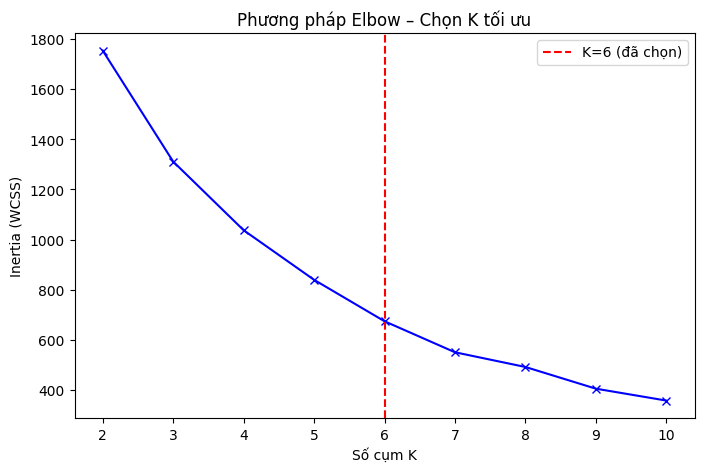

In [ ]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia_values = []
k_range = range(2, 11)  # Thử từ K=2 đến K=10
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)  # X đã StandardScaler
    inertia_values.append(km.inertia_)
    # inertia_: tổng bình phương khoảng cách mỗi điểm đến tâm cụm
    # → Càng nhỏ càng tốt, nhưng K lớn luôn nhỏ hơn
    # → Chọn K tại "khuỷu tay" (elbow point) – điểm giảm chậm lại
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, 'bx-')
plt.xlabel('Số cụm K')
plt.ylabel('Inertia (WCSS)')
plt.title('Phương pháp Elbow – Chọn K tối ưu')
plt.axvline(x=6, color='red', linestyle='--', label='K=6 (đã chọn)')
plt.legend()
plt.show()

In [36]:
import sqlite3

# Kết nối đến database (sẽ tạo mới file nếu chưa có)
conn = sqlite3.connect("london.db")

# Lưu DataFrame 'df' vào bảng 'stations'
# index=False để không lưu cột chỉ số vào database
df.to_sql("stations", conn, if_exists="replace", index=False)

print("✓ Đã lưu dữ liệu vào london.db thành công!")
conn.close()

✓ Đã lưu dữ liệu vào london.db thành công!


,station,cluster_name,passengers_2021,recovery_rate
0,North Greenwich,Mega Hub,11279522.0,16.985015
1,Old Street,Mega Hub,9635310.0,44.163690
2,Camden Town,Mega Hub,9118497.0,65.503781
3,Covent Garden,Mega Hub,7484432.0,361.560928
4,Knightsbridge,Mega Hub,7453212.0,66.951302
